# SoftVQ-VAE: Efficient 1D Continuous Tokenizer

In [4]:
import torch
from PIL import Image
import numpy as np
import requests
import sys 
sys.path.append('../')
from modelling.tokenizer import SoftVQModel
from matplotlib import pyplot as plt

In [5]:
def show_image(image, title=''):
    # image is [H, W, 3]
    assert image.shape[2] == 3
    plt.imshow(torch.clip((image * 0.5 + 0.5) * 255, 0, 255).int())
    plt.title(title, fontsize=16)
    plt.axis('off')
    return

## Load Model

In [6]:
vae = SoftVQModel.from_pretrained("SoftVQVAE/softvq-b-64")
vae = vae.eval()
if torch.cuda.is_available():
    vae = vae.cuda()
    device = torch.device('cuda')
    device_type = 'cuda'
else:
    device = torch.device('cpu')
    device_type = 'cpu'

config.json:   0%|          | 0.00/1.09k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/693M [00:00<?, ?B/s]

## Load Image

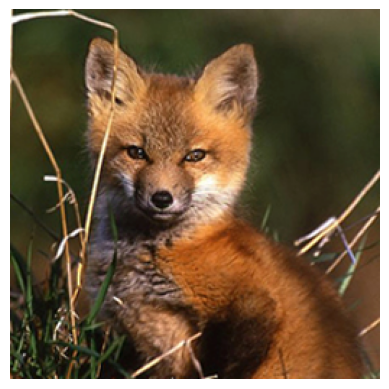

In [7]:
# load an image
img_url = 'https://user-images.githubusercontent.com/11435359/147738734-196fd92f-9260-48d5-ba7e-bf103d29364d.jpg' # fox, from ILSVRC2012_val_00046145
# img_url = 'https://user-images.githubusercontent.com/11435359/147743081-0428eecf-89e5-4e07-8da5-a30fd73cc0ba.jpg' # cucumber, from ILSVRC2012_val_00047851
img = Image.open(requests.get(img_url, stream=True).raw)
img = img.resize((256, 256))
img = np.array(img) / 255.

assert img.shape == (256, 256, 3)

# normalize by ImageNet mean and std
img = img - 0.5
img = img / 0.5

show_image(torch.tensor(img))

## Reconstruction

In [8]:
input_img = torch.tensor(img).permute(2, 0, 1).unsqueeze(0).float().to(device)
with torch.amp.autocast(device_type=device_type) and torch.no_grad():
    recon_img, _, _ = vae(input_img)
recon_img = recon_img[0].cpu().permute(1, 2, 0).numpy()

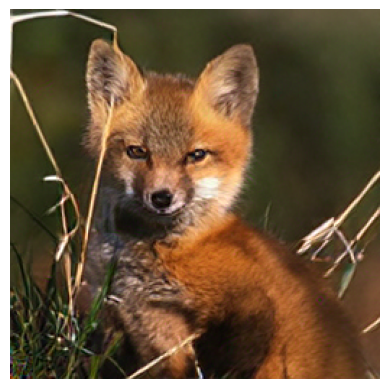

In [9]:
# visualization
show_image(torch.tensor(recon_img))